# Forecasting US Retail Sales of Sporting Goods, Hobby, Musical Instrument and Book Stores

**Time Series Analysis — project report**

Yassine Gharbi · EPF Montpellier, Data & AI (5A)

Data: U.S. Census Bureau, *Retail Sales: Sporting Goods, Hobby, Musical Instrument, and Book Stores* [MRTSSM451USN], retrieved from FRED, Federal Reserve Bank of St. Louis.

## 0. Introduction

### 0.1 Problem and business question

Stores selling sporting goods, hobby items, musical instruments and books run a seasonal business: December has been their best month in every year since 1992. The level of activity has also shifted several times over that period, most abruptly around 2020. A retailer or supplier who misjudges the December peak either runs out of stock at the busiest time of the year or is left with capital tied up in unsold inventory.

This report forecasts the **monthly sales of US sporting goods, hobby, musical instrument and book stores** and interprets every step of the analysis, both statistically and in business terms. The question it answers is:

> *How much will these stores sell in each of the coming months, and how much can a planner rely on that number?*

The forecast is meant to support four kinds of decisions:

- **Inventory and supply chain** — how much to order, and how early, ahead of the holiday peak.
- **Staffing** — how many seasonal employees to hire, and for which months.
- **Cash flow** — when revenue comes in relative to when suppliers must be paid.
- **Sector monitoring** — what lenders, commercial landlords and public authorities (sales-tax receipts) can expect from this retail segment.

### 0.2 Dataset

| | |
|---|---|
| **Series** | Retail Sales: Sporting Goods, Hobby, Musical Instrument, and Book Stores (United States) |
| **FRED identifier** | `MRTSSM451USN` |
| **Producer** | U.S. Census Bureau (release: *Monthly Retail Trade and Food Services*), retrieved from FRED (Federal Reserve Bank of St. Louis) |
| **Unit** | Millions of US dollars |
| **Seasonal adjustment** | **Not** seasonally adjusted |
| **Frequency** | Monthly |
| **Period covered** | January 1992 → July 2026 |
| **Observations** | 415, no missing values |

Source page: <https://fred.stlouisfed.org/series/MRTSSM451USN>

Three properties of the series shape the whole analysis:

1. **It is not seasonally adjusted.** The seasonal pattern is still in the data, which is exactly what a planner needs: the forecast must reproduce the December peak, not smooth it away.
2. **It is expressed in current dollars.** Growth in the series mixes volume growth and price increases, so periods of high inflation raise the level even if the quantities sold do not change.
3. **It aggregates four different kinds of stores.** Sporting goods, hobby, musical instrument and book stores are added together, so the series cannot tell which of them drives a given movement. It also measures a category of stores, not a product market: the same goods sold by other types of retailers are counted elsewhere.

### 0.3 Approach and plan

The analysis follows the **decomposition–reconstruction** logic of the course: a series is easier to understand and to forecast once it is split into a trend, a seasonal component and a residual. The components combine either by addition, $X_t = T_t + S_t + R_t$ (additive model), or by multiplication, $X_t = T_t \times S_t \times R_t$ (multiplicative model). Choosing between the two is the first modelling decision and is justified with the tools seen in class (band procedure, Buys-Ballot test, analysis of variance).

Three forecasting methods are then fitted and compared on the same held-out period:

1. **ETS / Holt-Winters** — exponential smoothing with trend and seasonal terms.
2. **SARIMA** — seasonal ARIMA, built from differencing and the ACF/PACF.
3. **Prophet** — additive regression model with trend changepoints and yearly seasonality.

All models are judged against two baselines (naive and seasonal naive) with MAE, MSE, RMSE and MAPE, on a chronological train/test split.

| Section | Content |
|---|---|
| 1 | Data loading and cleaning |
| 2 | Exploratory data analysis |
| 3 | Stationarity |
| 4 | ETS: decomposition and Holt-Winters |
| 5 | SARIMA |
| 6 | Prophet |
| 7 | Comparison of the forecasts |
| 8 | Conclusion |
| 9 | AI-usage policy |

Every output below is followed by a **technical reading** (what it means statistically) and a **business reading** (what it implies for a retailer, a distributor or a public authority).

### 0.4 Setup

Libraries, random seed, constants and plot style reused throughout the notebook. Model-specific imports are made in the section that uses them.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

DATA_PATH = "MRTSSM451USN.csv"   # relative path; the raw file is never modified
SERIES_ID = "MRTSSM451USN"
SEASONAL_PERIOD = 12             # monthly data, yearly seasonality
UNIT = "millions of USD"

pd.set_option("display.width", 120)

In [26]:
# One palette and one set of chart defaults for the whole report
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE = PALETTE[:2]
BLUE_LIGHT = "#cde2fb"                                                # light fill for boxes
BLUE_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]   # light to dark, for ordered values such as years
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"   # text: primary, secondary, axis labels
SURFACE, GRID, AXIS = "#fcfcfb", "#e1e0d9", "#c3c2b7"

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.figsize": (12, 5), "figure.dpi": 110,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": INK, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 13,
    "lines.linewidth": 2, "legend.frameon": False,
})

## 1. Data loading and cleaning

This section turns the raw file into a clean monthly series and checks whether anything in it has to be repaired before the analysis: time index, frequency, missing values, then outliers.

### 1.1 Loading the raw file

In [27]:
raw = pd.read_csv(DATA_PATH)

print(f"{raw.shape[0]} rows x {raw.shape[1]} columns")
print(raw.dtypes.to_string())
raw.head()

415 rows x 2 columns
observation_date      str
MRTSSM451USN        int64


,observation_date,MRTSSM451USN
0,1992-01-01,2982
1,1992-02-01,2534
2,1992-03-01,2687
3,1992-04-01,2750
4,1992-05-01,2799


**Technical reading.** The file has 415 rows and 2 columns. `observation_date` is read as text, so it is not yet a time axis. `MRTSSM451USN` is read directly as integers, which already rules out two problems: a non-numeric entry would have turned the column into text, and a missing value would have turned it into decimals.

**Business reading.** Each row is the total sales of one month across all US stores of the category, in millions of dollars. The first row reads 2,982: about 3.0 billion dollars sold in January 1992.

### 1.2 Building the time index

In [28]:
sales = (
    raw.assign(date=pd.to_datetime(raw["observation_date"]))
       .set_index("date")[SERIES_ID]
       .rename("sales")
       .astype(float)
       .sort_index()
)

print(f"Index type  : {type(sales.index).__name__}")
print(f"First month : {sales.index.min():%Y-%m}")
print(f"Last month  : {sales.index.max():%Y-%m}")
print(f"Spacing     : {pd.infer_freq(sales.index)}")

Index type  : DatetimeIndex
First month : 1992-01
Last month  : 2026-07
Spacing     : MS


**Technical reading.** The dates are now a `DatetimeIndex` and pandas infers the spacing `MS` (month start): every timestamp is the first day of a month. The date is only a label for the whole month's total, not an observation made on that day. The values are converted to decimals because the models used later expect them.

**Business reading.** The history covers 34 complete years (1992 to 2025) plus the first seven months of 2026. Since 2026 has no December yet, it cannot be compared with the other years on annual totals, and the most recent holiday peak available to judge a forecast is December 2025.

### 1.3 Frequency and missing values

In [29]:
expected = pd.date_range(sales.index.min(), sales.index.max(), freq="MS")

integrity = pd.Series({
    "observations": len(sales),
    "months between first and last date": len(expected),
    "missing months": len(expected.difference(sales.index)),
    "duplicated dates": int(sales.index.duplicated().sum()),
    "missing values": int(sales.isna().sum()),
    "zero or negative values": int((sales <= 0).sum()),
}, name="count")

sales = sales.asfreq("MS")  # attach the monthly frequency to the index
print(f"Index frequency: {sales.index.freqstr}")
integrity.to_frame()

Index frequency: MS


,count
observations,415
months between first and last date,415
missing months,0
duplicated dates,0
missing values,0
zero or negative values,0


**Technical reading.** There are 415 observations for the 415 months between the first and the last date: no missing month, no duplicated date, no missing value. Nothing has to be imputed. The frequency `MS` is now attached to the index, which the forecasting models need in order to date their forecasts. All values are strictly positive, so a log transform and multiplicative models remain possible.

**Business reading.** Every month since January 1992 is reported, including each of the 34 Decembers. The forecasts therefore rest on the complete published history and on no value estimated by us.

### 1.4 Summary statistics

In [30]:
summary = sales.describe().round(0)
summary["cv (%)"] = round(sales.std() / sales.mean() * 100, 1)

print(f"Minimum reached in {sales.idxmin():%Y-%m} | maximum reached in {sales.idxmax():%Y-%m}")
summary.to_frame()

Minimum reached in 1992-02 | maximum reached in 2025-12


,sales
count,415.0
mean,6088.0
std,1883.0
min,2534.0
25%,4903.0
50%,5931.0
75%,7154.0
max,12293.0
cv (%),30.9


**Technical reading.** Monthly sales range from 2,534 (February 1992) to 12,293 (December 2025), a factor of 4.9. The mean (6,088) is above the median (5,931): the distribution is skewed to the right. The minimum is a February at the very start of the series and the maximum a December at the very end, which shows a trend and a seasonal pattern acting together. These global statistics mix the two, so they describe a distribution that is not stable over time; this is the question taken up in Section 3 (stationarity).

**Business reading.** The "average month" of about 6.1 billion dollars is not a usable planning figure: actual months go from 2.5 to 12.3 billion. A planner needs one number per month of the year and per year, which is what the models of Sections 4 to 6 produce.

### 1.5 Outliers

The usual rule flags any value further than 1.5 times the interquartile range (IQR) from the quartiles. It is applied first to the raw values.

In [31]:
q1, q3 = sales.quantile([0.25, 0.75])
lower, upper = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
iqr_flags = sales[(sales < lower) | (sales > upper)]

print(f"IQR bounds     : {lower:,.0f} to {upper:,.0f} {UNIT}")
print(f"Months flagged : {len(iqr_flags)}")
print(f"Calendar months: {sorted(iqr_flags.index.month.unique().tolist())}")
print(f"Years          : {iqr_flags.index.year.tolist()}")

IQR bounds     : 1,526 to 10,530 millions of USD
Months flagged : 13
Calendar months: [12]
Years          : [2005, 2006, 2007, 2012, 2013, 2014, 2015, 2016, 2021, 2022, 2023, 2024, 2025]


**Technical reading.** The rule flags 13 months and all of them are Decembers, in the years when the level was highest (2005 to 2007, 2012 to 2016, 2021 to 2025). These are seasonal peaks, not anomalies: the rule compares each month with the whole 34-year distribution and ignores both that December is always high and that the level has changed. It is not suited to a seasonal series with a trend.

**Business reading.** December is not an abnormal month to be removed; it is the month the forecast is most needed for. Cleaning the data with this rule would delete exactly what a retailer wants predicted.

**A screening adapted to the series.** Each month is instead compared with the same month one year earlier. The year-over-year change removes the seasonal pattern (same calendar month) and most of the trend. Unusual changes are flagged with the modified z-score of Iglewicz and Hoaglin (1993), built on the median and the median absolute deviation (MAD), with their recommended threshold of 3.5.

In [32]:
yoy = sales.pct_change(SEASONAL_PERIOD) * 100            # % change vs the same month, previous year

median = yoy.median()
mad = (yoy - median).abs().median()                       # median absolute deviation
robust_z = 0.6745 * (yoy - median) / mad                  # modified z-score
band = 3.5 * mad / 0.6745                                 # threshold expressed in points of change

outliers = pd.DataFrame({
    "sales": sales,
    "same month, previous year": sales.shift(SEASONAL_PERIOD),
    "yoy change (%)": yoy.round(1),
    "modified z-score": robust_z.round(2),
})[robust_z.abs() > 3.5]

print(f"Median change: {median:+.1f} % | MAD: {mad:.1f} points | flagging band: {median - band:+.1f} % to {median + band:+.1f} %")
print(f"Spread of the changes: standard deviation {yoy.std():.1f} points | robust equivalent (MAD / 0.6745) {mad / 0.6745:.1f} points")
print(f"Months flagged: {len(outliers)} of {yoy.notna().sum()} screened")
outliers

Median change: +2.7 % | MAD: 3.5 points | flagging band: -15.2 % to +20.6 %
Spread of the changes: standard deviation 10.1 points | robust equivalent (MAD / 0.6745) 5.1 points
Months flagged: 9 of 403 screened


,sales,"same month, previous year",yoy change (%),modified z-score
date,,,,
2018-12-01,8798.0,10428.0,-15.6,-3.58
2020-03-01,4955.0,5983.0,-17.2,-3.88
2020-04-01,3264.0,5887.0,-44.6,-9.22
2020-06-01,7822.0,6291.0,24.3,4.22
2020-09-01,7193.0,5950.0,20.9,3.55
2021-01-01,6858.0,5514.0,24.4,4.23
2021-03-01,8560.0,4955.0,72.8,13.67
2021-04-01,8035.0,3264.0,146.2,27.99
2021-05-01,7963.0,5931.0,34.3,6.16


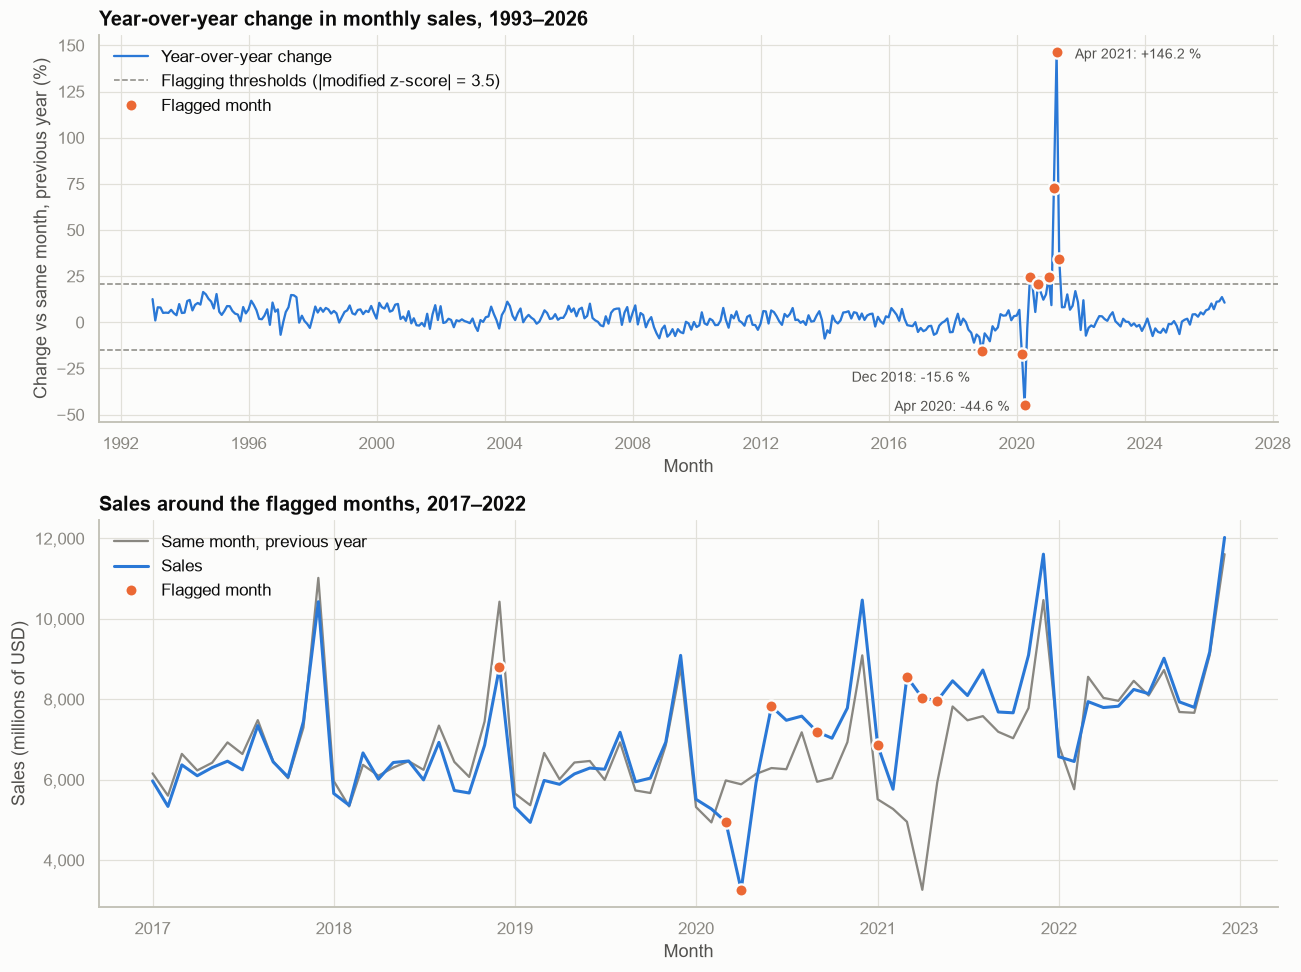

In [33]:
fig, (ax_change, ax_sales) = plt.subplots(2, 1, figsize=(12, 9))
dot = dict(marker="o", ls="", color=ORANGE, ms=8, mec=SURFACE, mew=1.5, label="Flagged month", zorder=3)

# Top panel: year-over-year change over the whole history
ax_change.plot(yoy, color=BLUE, lw=1.5, label="Year-over-year change")
ax_change.axhline(median + band, color=MUTED, lw=1, ls="--", label="Flagging thresholds (|modified z-score| = 3.5)")
ax_change.axhline(median - band, color=MUTED, lw=1, ls="--")
ax_change.plot(outliers["yoy change (%)"], **dot)
for month, offset in {"2018-12": (-8, -20), "2020-04": (-10, -4), "2021-04": (12, -4)}.items():
    value = outliers.loc[month, "yoy change (%)"].iloc[0]
    ax_change.annotate(f"{pd.Timestamp(month):%b %Y}: {value:+.1f} %", (pd.Timestamp(month), value),
                       xytext=offset, textcoords="offset points", fontsize=9, color=INK_2,
                       ha="right" if offset[0] < 0 else "left")
ax_change.set(title="Year-over-year change in monthly sales, 1993–2026",
              xlabel="Month", ylabel="Change vs same month, previous year (%)")
ax_change.legend(loc="upper left")

# Bottom panel: sales around the flagged months
window = slice("2017-01", "2022-12")
ax_sales.plot(sales.shift(SEASONAL_PERIOD)[window], color=MUTED, lw=1.5, label="Same month, previous year")
ax_sales.plot(sales[window], color=BLUE, label="Sales")
ax_sales.plot(outliers.loc[window, "sales"], **dot)
ax_sales.set(title="Sales around the flagged months, 2017–2022",
             xlabel="Month", ylabel=f"Sales ({UNIT})")
ax_sales.yaxis.set_major_formatter("{x:,.0f}")
ax_sales.legend(loc="upper left")

fig.tight_layout()
plt.show()

**Technical reading.**

- Sales typically grow by 2.7 % from one year to the next. A month is flagged when its change falls outside the band from −15.2 % to +20.6 %. The median and the MAD are used instead of the mean and the standard deviation because the latter are inflated by the very values being looked for: the standard deviation of the changes is 10.1 points, against a robust equivalent of 5.1.
- 9 months out of 403 are flagged (the first 12 months have no previous year to be compared with). Eight of them lie between March 2020 and May 2021; the ninth is December 2018.
- **April 2020** is the largest drop of the whole series: 3,264 against 5,887 a year earlier (−44.6 %, z-score −9.22), after a first fall in March 2020 (−17.2 %).
- **June 2020, September 2020 and January 2021** are flagged on the upside (+21 % to +24 %): sales rebound well above their level of the previous year.
- **March to May 2021** show the largest increases (+72.8 %, +146.2 %, +34.3 %). The March and April figures are partly a base effect, since they are compared with the two collapsed months of 2020. They are not only that: April 2021 (8,035) is still 36 % above April 2019 (5,887).
- The bottom panel shows the pattern behind these flags. Sales run above the previous-year line from June 2020 to the end of 2021, then only match it in 2022: the level stepped up and did not come back down. This is a shock followed by a level shift, not a set of isolated erroneous points.
- **December 2018** is an isolated case, just beyond the threshold: 8,798 against 10,428 in December 2017 (−15.6 %, z-score −3.58).

**Business reading.**

- April 2020 coincides with the first COVID-19 lockdowns in the United States. Stores sold about 2.6 billion dollars less than in April 2019, close to half a month of revenue. No model trained on past sales could have announced it. For cash-flow planning this is the argument for reading a forecast with its prediction interval and for keeping a reserve, rather than relying on the point forecast alone.
- From June 2020 the problem was reversed: in the flagged months, sales ran more than 20 % above the previous year, which for a retailer means a risk of stock-outs rather than of excess inventory. The causes of this rebound are examined in Section 6, where the changepoints are compared with documented events.
- December 2018 matters most for inventory planning: stock for the holiday peak is ordered months ahead, and that December came in 16 % below the previous one. The series itself does not say why. A sector-specific event is a possible explanation and has to be checked before it is cited.

**Decision: no value is modified.** The flagged months are real sales published by the Census Bureau, not recording errors. Replacing or smoothing them would make the history look calmer than it was and would lead to prediction intervals that are too narrow. The alternative, replacing the 2020 trough by an interpolated value, is therefore not applied. Two consequences follow for the rest of the report:

- The 2020–2021 shock is part of the data the models learn from. It will weigh on the residual diagnostics of ETS and SARIMA and on the changepoints detected by Prophet; the table `outliers` is kept to read those results.
- No flagged month falls in the last 24 months of the series, so the test period is free of them whether the horizon is 12 or 24 months.

The series `sales` (415 monthly observations, frequency `MS`, no missing value) is the object used in all the following sections.

## 2. Exploratory data analysis

This section describes the series before any modelling: its overall shape, its seasonal pattern, and how its level and its variability move over time. It ends with the train/test split used by all the models.

### 2.1 Time plot

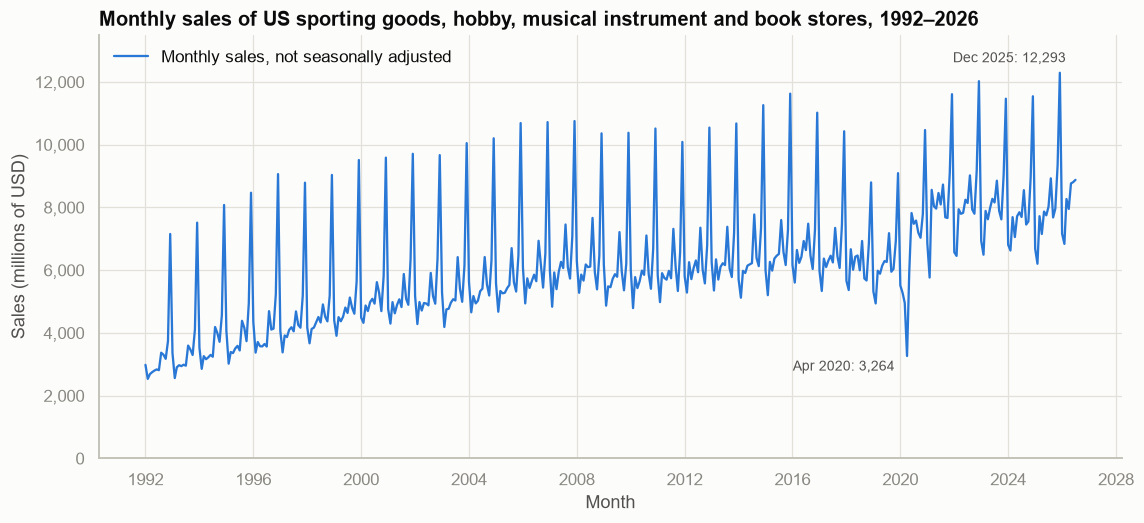

In [34]:
fig, ax = plt.subplots()
ax.plot(sales, color=BLUE, lw=1.5, label="Monthly sales, not seasonally adjusted")
for month, offset, va in [(sales.idxmax(), (4, 5), "bottom"), (pd.Timestamp("2020-04-01"), (-8, -3), "top")]:
    ax.annotate(f"{month:%b %Y}: {sales[month]:,.0f}", (month, sales[month]), xytext=offset,
                textcoords="offset points", ha="right", va=va, fontsize=9, color=INK_2)
ax.set(title="Monthly sales of US sporting goods, hobby, musical instrument and book stores, 1992–2026",
       xlabel="Month", ylabel=f"Sales ({UNIT})", ylim=(0, 13_500))
ax.yaxis.set_major_formatter("{x:,.0f}")
ax.legend(loc="upper left")
plt.show()

**Technical reading.** Three features are visible.

- **A long-term movement.** The level rises over the period, but not along a straight line: it climbs until the late 2000s, moves sideways for about a decade, then sits on a clearly higher plateau after 2020.
- **A pattern that repeats every 12 months**, dominated by a sharp spike each December. This is a seasonal component of period 12.
- **One break in this regularity**: the trough of April 2020 (3,264), followed by a fast recovery.

With a trend and a seasonal pattern, the series is not stationary as it stands (Section 3). The December spikes also do not seem to get taller as the level rises, which is a first hint for the choice between an additive and a multiplicative model; subsections 2.2 and 2.4 look at it more closely.

**Business reading.** The calendar of the year is the same every year, so a retailer knows *when* the peak comes. What is uncertain is the level around which the year is played, and that level has shifted more than once, in 2020 without warning. A useful forecast has to get both right: the seasonal calendar and the current level.

### 2.2 Seasonal plot

The series is rearranged in a table with one row per year and one column per month (the Buys-Ballot layout seen in class). Only complete years are kept, so 2026 is left out. Each month is also divided by the average month of its year, which puts all the years on a common scale.

In [35]:
from matplotlib.colors import LinearSegmentedColormap

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

complete = sales[:"2025"]                                     # 2026 stops in July
by_year = complete.groupby([complete.index.year, complete.index.month]).first().unstack()
by_year.index.name, by_year.columns = "year", MONTHS
seasonal_ratio = by_year.div(by_year.mean(axis=1), axis=0)    # month / average month of the same year

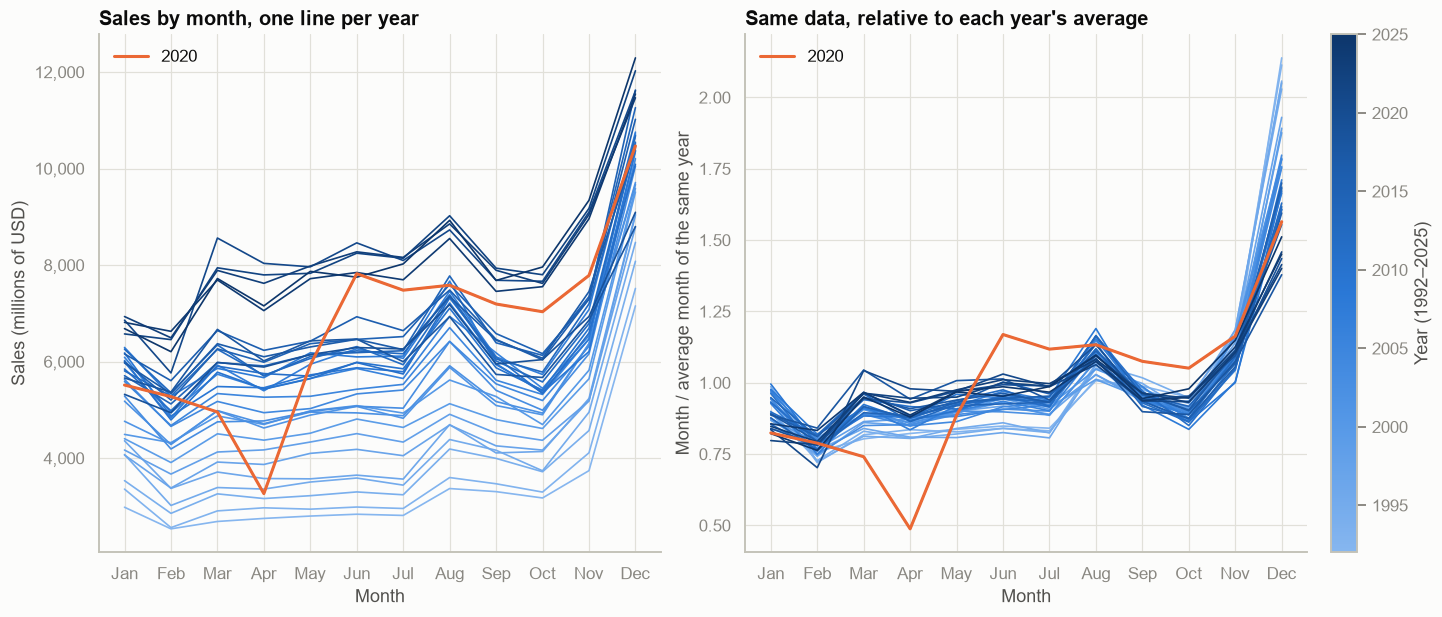

Highest month of the year: {'Dec': 34}
Lowest month of the year : {'Feb': 33, 'Apr': 1}


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
1992,0.89,0.76,0.80,0.82,0.84,0.85,0.84,1.01,0.99,0.95,1.12,2.14
2000,0.84,0.81,0.91,0.88,0.93,0.95,0.92,1.05,0.98,0.88,1.08,1.79
2008,0.98,0.82,0.91,0.88,0.96,0.95,0.95,1.19,0.92,0.84,1.00,1.61
2016,0.89,0.81,0.96,0.90,0.93,1.00,0.96,1.08,0.93,0.87,1.06,1.59
2019,0.84,0.78,0.94,0.93,0.97,0.99,0.99,1.13,0.94,0.95,1.09,1.44
2020,0.82,0.79,0.74,0.49,0.89,1.17,1.12,1.13,1.07,1.05,1.16,1.56
2025,0.82,0.76,0.95,0.88,0.97,0.95,0.99,1.10,0.94,0.98,1.15,1.51
average 1992–2025,0.90,0.78,0.91,0.86,0.91,0.95,0.93,1.09,0.96,0.91,1.10,1.71


In [36]:
year_cmap = LinearSegmentedColormap.from_list("years", BLUE_RAMP)
year_norm = plt.Normalize(by_year.index.min(), by_year.index.max())
panels = [(by_year, f"Sales ({UNIT})", "Sales by month, one line per year"),
          (seasonal_ratio, "Month / average month of the same year", "Same data, relative to each year's average")]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), layout="constrained")
for ax, (table, ylabel, title) in zip(axes, panels):
    for year, row in table.iterrows():
        ax.plot(MONTHS, row, color=year_cmap(year_norm(year)), lw=1.1)
    ax.plot(MONTHS, table.loc[2020], color=ORANGE, label="2020")
    ax.set(title=title, xlabel="Month", ylabel=ylabel)
    ax.legend(loc="upper left")
axes[0].yaxis.set_major_formatter("{x:,.0f}")
fig.colorbar(plt.cm.ScalarMappable(norm=year_norm, cmap=year_cmap), ax=axes, label="Year (1992–2025)", pad=0.02)
plt.show()

print(f"Highest month of the year: {by_year.idxmax(axis=1).value_counts().to_dict()}")
print(f"Lowest month of the year : {by_year.idxmin(axis=1).value_counts().to_dict()}")
pd.concat([seasonal_ratio.loc[[1992, 2000, 2008, 2016, 2019, 2020, 2025]],
           seasonal_ratio.mean().rename("average 1992–2025").to_frame().T]).round(2)

**Technical reading.**

- **The calendar is stable.** December is the highest month in all 34 complete years, and February the lowest in 33 of them (the exception is 2020, where it is April).
- **Average profile.** A December is worth 1.71 times the average month of its year. August and November come next, both about 10 % above average. Every other month is below average, down to 0.78 in February.
- **Left panel.** The lines have the same shape and are stacked roughly in chronological order, light at the bottom and dark at the top: this vertical stacking is the trend. The 2020 line breaks the shape, with April at 0.49 of the year's average and then every month from June to November above it.
- **Right panel.** Once each year is put on the same scale, the profiles overlap closely from January to November but fan out in December. The December ratio falls from 2.14 in 1992 to 1.79 in 2000, 1.61 in 2008, 1.59 in 2016 and 1.51 in 2025. The seasonal pattern is stable in its timing, not in its relative size: a single set of constant multiplicative coefficients could not describe the whole history.

**Business reading.**

- The holiday season remains the main event of the year, but the year depends on it less than it used to: December was worth more than two average months in the early 1990s and about one and a half today. Revenue is spread more evenly over the year, so cash flow depends less on a single month. The series does not say why this happened.
- There are two secondary highs to plan for, in August and in November. The August one is consistent with back-to-school purchases, although the series alone cannot confirm it.
- February is the low point of every normal year: the natural window for clearing inventory and for scheduling leave and maintenance.

### 2.3 Boxplot by month

Each box gathers all the values observed for one calendar month, across the 35 years (34 for August to December).

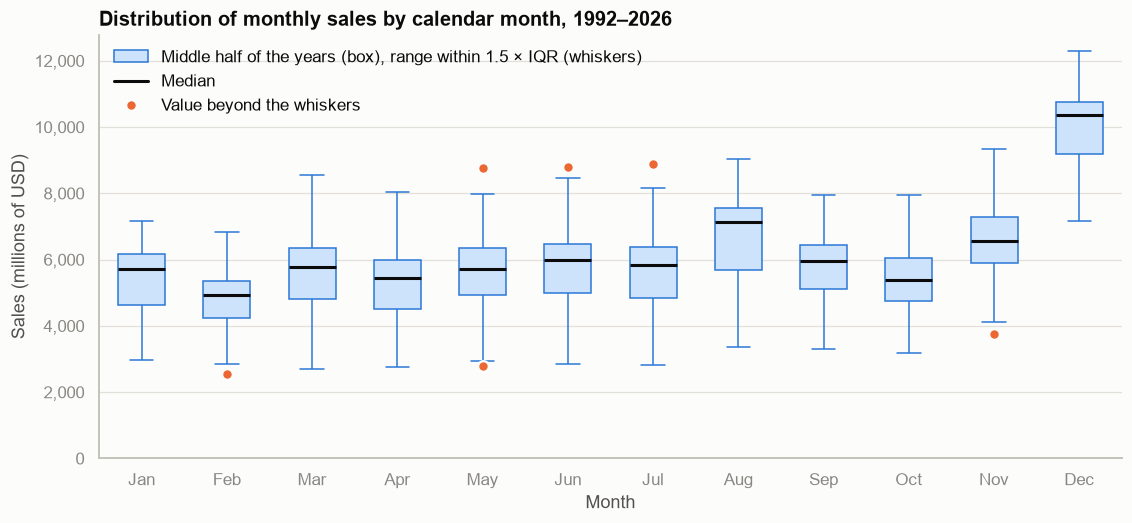

Values beyond the whiskers: Feb 1992, May 1992, Nov 1992, Feb 1993, May 2026, Jun 2026, Jul 2026


,count,min,25%,50%,75%,max
Jan,35.0,2982.0,4627.0,5707.0,6169.0,7160.0
Feb,35.0,2534.0,4236.0,4940.0,5344.0,6838.0
Mar,35.0,2687.0,4812.0,5780.0,6358.0,8560.0
Apr,35.0,2750.0,4498.0,5434.0,6000.0,8035.0
May,35.0,2799.0,4922.0,5724.0,6337.0,8764.0
Jun,35.0,2837.0,5004.0,5986.0,6464.0,8809.0
Jul,35.0,2812.0,4852.0,5850.0,6390.0,8879.0
Aug,34.0,3369.0,5683.0,7142.0,7557.0,9022.0
Sep,34.0,3305.0,5110.0,5944.0,6430.0,7936.0
Oct,34.0,3174.0,4746.0,5398.0,6063.0,7960.0


In [37]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

month = pd.Categorical(sales.index.strftime("%b"), categories=MONTHS, ordered=True)
flier = dict(marker="o", markersize=7, markerfacecolor=ORANGE, markeredgecolor=SURFACE, markeredgewidth=1.5)

fig, ax = plt.subplots()
sns.boxplot(x=month, y=sales.to_numpy(), ax=ax, color=BLUE_LIGHT, linecolor=BLUE, saturation=1, width=0.55,
            medianprops=dict(color=INK, linewidth=2), flierprops=flier)
ax.set(title="Distribution of monthly sales by calendar month, 1992–2026",
       xlabel="Month", ylabel=f"Sales ({UNIT})", ylim=(0, None))
ax.yaxis.set_major_formatter("{x:,.0f}")
ax.legend(loc="upper left", handles=[
    Patch(facecolor=BLUE_LIGHT, edgecolor=BLUE, label="Middle half of the years (box), range within 1.5 × IQR (whiskers)"),
    Line2D([], [], color=INK, lw=2, label="Median"),
    Line2D([], [], ls="", label="Value beyond the whiskers", **flier),
])
plt.show()

by_month = sales.groupby(sales.index.month)
q1, q3 = by_month.transform("quantile", 0.25), by_month.transform("quantile", 0.75)
beyond = sales[(sales < q1 - 1.5 * (q3 - q1)) | (sales > q3 + 1.5 * (q3 - q1))]
print("Values beyond the whiskers:", ", ".join(f"{d:%b %Y}" for d in beyond.index))
sales.groupby(month, observed=True).describe()[["count", "min", "25%", "50%", "75%", "max"]].round(0)

**Technical reading.**

- **December stands apart.** Its median is 10,370, against 4,940 (February) to 7,142 (August) for the other months. The lowest December ever recorded (7,154) is still above the median of every other month.
- **The other eleven boxes overlap widely**, each with an interquartile range between about 1,100 and 1,900. This spread is not noise around a monthly level: it is 34 years of trend stacked inside each box.
- **The points beyond the whiskers confirm it.** They come from the two ends of the history: 1992 and 1993 at the bottom, May to July 2026 at the top. Conversely April 2020, the largest shock of the series (Section 1), lies inside the April whiskers. A boxplot by month ranks the months reliably; it cannot be used to detect anomalies in a series with a trend.

**Business reading.**

- The ranking of the months is the robust message for planning: December far ahead, then August and November, February last. It has held for 34 years.
- May, June and July 2026 are the highest values ever recorded for these months. Sales are currently at a record level, so a plan built on the historical average of a month would understock; the recent level has to be the starting point.

### 2.4 Rolling mean and standard deviation

Both statistics are computed on the last 12 months. Each window contains every calendar month exactly once, so the seasonal pattern cancels out of the mean, which then shows the trend. The standard deviation measures how far the months of the window spread around that mean, that is, the size of the seasonal swing. The shaded periods are the US recessions dated by the NBER.

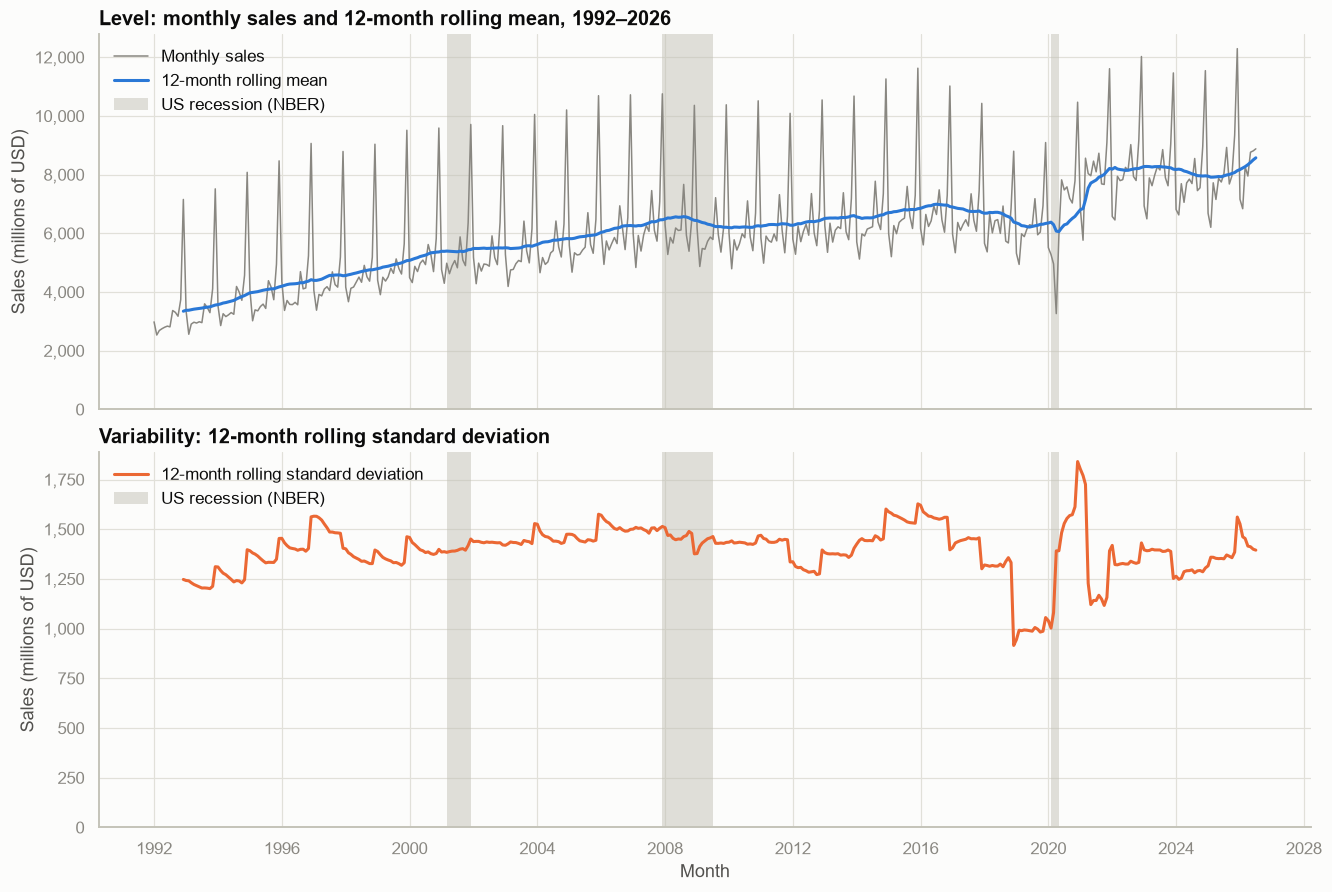

,rolling mean,rolling std,std / mean (%)
date,,,
1992-12-01,3345.0,1247.0,37.3
2000-12-01,5365.0,1399.0,26.1
2008-08-01,6568.0,1463.0,22.3
2010-02-01,6188.0,1441.0,23.3
2016-07-01,6991.0,1554.0,22.2
2019-12-01,6336.0,1056.0,16.7
2020-05-01,6058.0,1391.0,23.0
2020-12-01,6692.0,1840.0,27.5
2021-12-01,8210.0,1391.0,16.9


In [38]:
RECESSIONS = [("2001-03", "2001-11"), ("2007-12", "2009-06"), ("2020-02", "2020-04")]   # NBER peak and trough months
rolling_mean = sales.rolling(SEASONAL_PERIOD).mean()
rolling_std = sales.rolling(SEASONAL_PERIOD).std()

fig, (ax_mean, ax_std) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, layout="constrained")
ax_mean.plot(sales, color=MUTED, lw=1, label="Monthly sales")
ax_mean.plot(rolling_mean, color=BLUE, label="12-month rolling mean")
ax_std.plot(rolling_std, color=ORANGE, label="12-month rolling standard deviation")
for ax in (ax_mean, ax_std):
    for i, (start, end) in enumerate(RECESSIONS):
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end) + pd.offsets.MonthEnd(0), color=AXIS, alpha=0.5, lw=0,
                   label="US recession (NBER)" if i == 0 else None)
    ax.set(ylabel=f"Sales ({UNIT})", ylim=(0, None))
    ax.yaxis.set_major_formatter("{x:,.0f}")
    ax.legend(loc="upper left")
ax_mean.set_title("Level: monthly sales and 12-month rolling mean, 1992–2026")
ax_std.set(title="Variability: 12-month rolling standard deviation", xlabel="Month")
plt.show()

turning_points = ["1992-12", "2000-12", "2008-08", "2010-02", "2016-07", "2019-12", "2020-05", "2020-12", "2021-12", "2025-02", "2026-07"]
pd.DataFrame({"rolling mean": rolling_mean, "rolling std": rolling_std,
              "std / mean (%)": rolling_std / rolling_mean * 100}).loc[turning_points].round({"rolling mean": 0, "rolling std": 0, "std / mean (%)": 1})

The dates in the table are the first full window (December 1992) and the turning points of the rolling mean read from the chart.

**Technical reading.**

- **The mean is not constant, and its path is not a straight line.** It rises from 3,345 at the end of 1992 to 6,568 in August 2008, falls to 6,188 in February 2010 (−5.8 %), recovers to 6,991 in July 2016, then declines to 6,336 by December 2019 (−9.4 %). After a low of 6,058 in May 2020 it jumps to 8,210 in December 2021 (+35.5 % in 19 months), eases to 7,913 in February 2025 and reaches 8,573 in July 2026, the highest value of the series.
- **Recessions leave different marks.** In 2001 the mean only flattens; in 2007–2009 it falls; in 2020 it dips briefly and then steps up. The decline of 2017–2019, on the other hand, happens outside any recession: it is specific to this sector.
- **Consequences for the models.** The series is not stationary in mean (Section 3), and a single linear trend would misrepresent it. The models need a trend that can change over time: smoothing for ETS, differencing for SARIMA, changepoints for Prophet.
- **The standard deviation does not follow the level.** It is 1,247 at the end of 1992 and 1,395 in July 2026, while the mean was multiplied by 2.6 in between. Relative to the mean, it falls from 37.3 % to 16.3 %. Over three decades it stays in a band of roughly 1,200 to 1,600, with two excursions: a low of about 1,000 in 2019, when the December peak was at its weakest (ratio of 1.44, see 2.2), and a high of 1,840 at the end of 2020, when the window contains both the April trough and the rebound.
- **Reading for the decomposition.** Seasonal swings of about the same size in dollars, whatever the level, are the signature of an additive structure. In a multiplicative one, the standard deviation would grow with the mean and their ratio would stay constant. This is only a visual indication: the formal choice is made in Section 4, on the training set, with the band procedure and the Buys-Ballot test.

**Business reading.**

- The underlying level is about 8.6 billion dollars a month, a record. The history has three regimes: growth until 2008, a long plateau with a decline at its end, and a higher plateau since 2021. The growth of the 1990s is therefore not something to extrapolate.
- The 2017–2019 decline is a reminder that this sector can shrink while the economy grows. A lender or a landlord watching it cannot rely on the general business cycle alone.
- The seasonal swing is roughly a fixed amount of dollars, not a fixed share of sales. For a retailer, the extra stock and staff needed for the peak have not grown in line with annual revenue.
- The series is in current dollars. Part of the higher level since 2021 may reflect higher prices rather than more goods sold, which matters for anyone reading it as a volume indicator.

### 2.5 Train/test split

The models are fitted on the first part of the series and judged on the last part, which they never see. Two horizons were considered:

- **12 months**: one more year of training data and easier forecasts, but a single December to judge the peak on.
- **24 months**: two Decembers, so the error on the peak is measured twice; in exchange, the forecasts go up to 24 steps ahead and 12 fewer months are available for training.

The 24-month horizon is retained, because the December peak is what the business case is about.

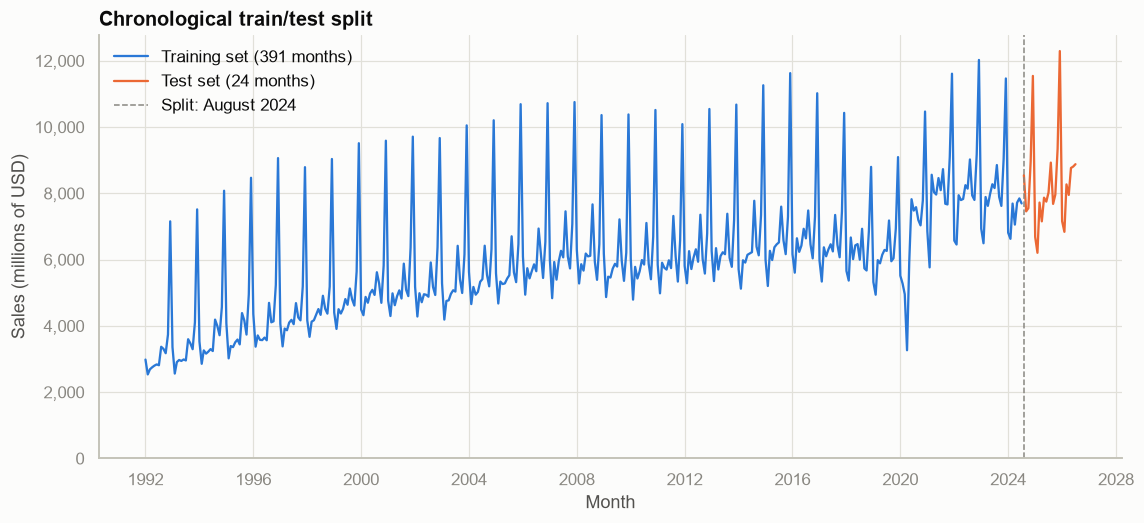

,first month,last month,months,Decembers,average monthly sales
training set,1992-01,2024-07,391,32,5954
"training set, last 12 months",2023-08,2024-07,12,1,8027
"test set, months 1 to 12",2024-08,2025-07,12,1,7955
"test set, months 13 to 24",2025-08,2026-07,12,1,8573


In [39]:
TEST_HORIZON = 24   # months held out for evaluation

train, test = sales.iloc[:-TEST_HORIZON], sales.iloc[-TEST_HORIZON:]

fig, ax = plt.subplots()
ax.plot(train, color=BLUE, lw=1.5, label=f"Training set ({len(train)} months)")
ax.plot(test, color=ORANGE, lw=1.5, label=f"Test set ({len(test)} months)")
ax.axvline(test.index[0], color=MUTED, lw=1, ls="--", label=f"Split: {test.index[0]:%B %Y}")
ax.set(title="Chronological train/test split", xlabel="Month", ylabel=f"Sales ({UNIT})", ylim=(0, None))
ax.yaxis.set_major_formatter("{x:,.0f}")
ax.legend(loc="upper left")
plt.show()

parts = {"training set": train, "training set, last 12 months": train.iloc[-12:],
         "test set, months 1 to 12": test.iloc[:12], "test set, months 13 to 24": test.iloc[12:]}
pd.DataFrame({name: {"first month": f"{part.index[0]:%Y-%m}", "last month": f"{part.index[-1]:%Y-%m}",
                     "months": len(part), "Decembers": int((part.index.month == 12).sum()),
                     "average monthly sales": round(part.mean())} for name, part in parts.items()}).T

**Technical reading.**

- The split is chronological: 391 months for training (January 1992 to July 2024) and the last 24 for testing (August 2024 to July 2026), 5.8 % of the data. The observations are never shuffled: their order carries the information, and shuffling would let a model learn from the future.
- The test set contains two Decembers (2024 and 2025). All models and both baselines are evaluated on exactly these 24 months.
- **The test period is not a quiet one.** Its first 12 months average 7,955, slightly below the last 12 months of training (8,027); its last 12 months average 8,573, which is 7.8 % higher. A model fitted up to July 2024 has only seen sales drifting down since the end of 2021 and has no way of knowing about this recovery. Larger errors are therefore to be expected in the second year. This is noted here to read the errors correctly in Section 7, not to tune the models.

**Business reading.** The test reproduces the position of a planner in August 2024 who has to prepare the next two holiday seasons with the data available at that date. The second year shows what such a planner faces in practice: the forecast is made before the market turns, so the plan must leave room to adjust orders upward as new months come in.

### 2.6 What the exploration implies for the models

- **Seasonality**: period 12, with a stable calendar (December peak, February low, secondary highs in August and November). All three models need a seasonal term, and the seasonal naive forecast will be a demanding baseline.
- **Trend**: not linear, with changes of level in 2008–2010, 2017–2019 and 2020–2021. The models must let the trend evolve.
- **Seasonal amplitude**: about constant in dollars and shrinking relative to the level. An additive structure is the leading candidate, to be tested in Section 4.
- **Shock**: the 2020–2021 episode is inside the training set and will influence every fit.

These observations describe the whole series. From Section 3 onward, every test, transformation and model uses `train` only.

## 3. Stationarity

A series is stationary when its statistical properties do not depend on the date: a constant mean, a constant variance, and an autocorrelation that depends only on the distance between two observations. SARIMA assumes that the series becomes stationary once it has been differenced, and its orders $d$ and $D$ are the numbers of regular and seasonal differences needed to get there. This section determines them.

Everything is computed on the training set. The series is kept in its original unit, without a log transform, because subsection 2.4 showed that its variability does not grow with its level; Section 4 tests this formally.

### 3.1 Two complementary tests

| Test | Null hypothesis $H_0$ | A p-value below 0.05 means |
|---|---|---|
| ADF (Augmented Dickey-Fuller) | the series has a unit root: it is **non-stationary** | $H_0$ rejected: evidence of stationarity |
| KPSS | the series is **stationary** | $H_0$ rejected: evidence of non-stationarity |

The two tests have opposite null hypotheses, and failing to reject a null hypothesis does not prove it. They are therefore read together, at the 5 % level:

- ADF rejects and KPSS does not: **stationary**;
- ADF does not reject and KPSS does: **non-stationary**;
- any other combination: the tests disagree and the result is treated as inconclusive.

Both tests can be run around a constant (`"c"`) or around a linear trend (`"ct"`). The number of lags is chosen automatically (AIC for ADF). The KPSS p-value is only tabulated between 0.01 and 0.10, so it is reported as "< 0.01" or "> 0.10" outside this range.

In [40]:
import warnings

from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.stattools import adfuller, kpss

ALPHA = 0.05


def stationarity_tests(series, regression="c"):
    """ADF (H0: unit root) and KPSS (H0: stationarity) on one series, read at the 5 % level."""
    x = series.dropna()
    adf_stat, adf_p, *_ = adfuller(x, regression=regression, autolag="AIC", result_object=False)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)   # p-value outside the tabulated range
        kpss_stat, kpss_p, _, kpss_crit = kpss(x, regression=regression, nlags="auto", result_object=False)
    adf_stationary, kpss_stationary = adf_p < ALPHA, kpss_p > ALPHA
    if adf_stationary != kpss_stationary:
        conclusion = "tests disagree"
    else:
        conclusion = "stationary" if adf_stationary else "non-stationary"
    return {
        "ADF statistic": round(adf_stat, 2),
        "ADF p-value": "< 0.001" if adf_p < 0.001 else f"{adf_p:.3f}",
        "KPSS statistic": round(kpss_stat, 3),
        "KPSS 5 % critical value": kpss_crit["5%"],
        "KPSS p-value": "< 0.01" if kpss_p <= 0.01 else "> 0.10" if kpss_p >= 0.10 else f"{kpss_p:.3f}",
        "conclusion at 5 %": conclusion,
    }


def moments(series):
    """Mean, spread and the two autocorrelations that reveal a trend (lag 1) and a seasonal pattern (lag 12)."""
    x = series.dropna()
    return {"mean": round(x.mean(), 1), "standard deviation": round(x.std(), 1),
            "autocorrelation, lag 1": round(x.autocorr(1), 2),
            "autocorrelation, lag 12": round(x.autocorr(SEASONAL_PERIOD), 2)}

### 3.2 The series in level

In [41]:
pd.DataFrame({
    "level, around a constant": stationarity_tests(train, "c"),
    "level, around a linear trend": stationarity_tests(train, "ct"),
}).T

,ADF statistic,ADF p-value,KPSS statistic,KPSS 5 % critical value,KPSS p-value,conclusion at 5 %
"level, around a constant",-1.49,0.538,3.107,0.463,< 0.01,non-stationary
"level, around a linear trend",-3.18,0.088,0.34,0.146,< 0.01,non-stationary


**Technical reading.**

- **Around a constant.** ADF does not reject the unit root (statistic −1.49, p = 0.538) and KPSS rejects stationarity (3.107, far above its critical value of 0.463). The two tests agree: the series is non-stationary.
- **Around a linear trend.** The conclusion is the same: ADF still does not reject at 5 % (−3.18, p = 0.088) and KPSS still rejects (0.340 against 0.146). The series is not stationary around a straight line either, which matches the broken trend seen in 2.4.
- **Consequence.** In the terms of the course, the trend is random rather than deterministic: it cannot be removed by fitting a function of time and subtracting it. It has to be removed by a filter, here differencing.

**Business reading.** There is no "normal" level that sales come back to, and no fixed growth line either. The long-run average of the training period (5,954) is not a reference for planning, and a change of level, such as the one of 2021, stays in the series instead of fading out. The best starting point for a forecast is the level reached most recently.

### 3.3 Regular and seasonal differencing

Two differences are available:

- the **regular difference** $\nabla y_t = y_t - y_{t-1}$, the change from one month to the next, which removes a trend;
- the **seasonal difference** $\nabla_{12}\, y_t = y_t - y_{t-12}$, the change from the same month one year earlier, which removes a seasonal pattern of period 12.

Three candidates are compared: each difference alone, then both.

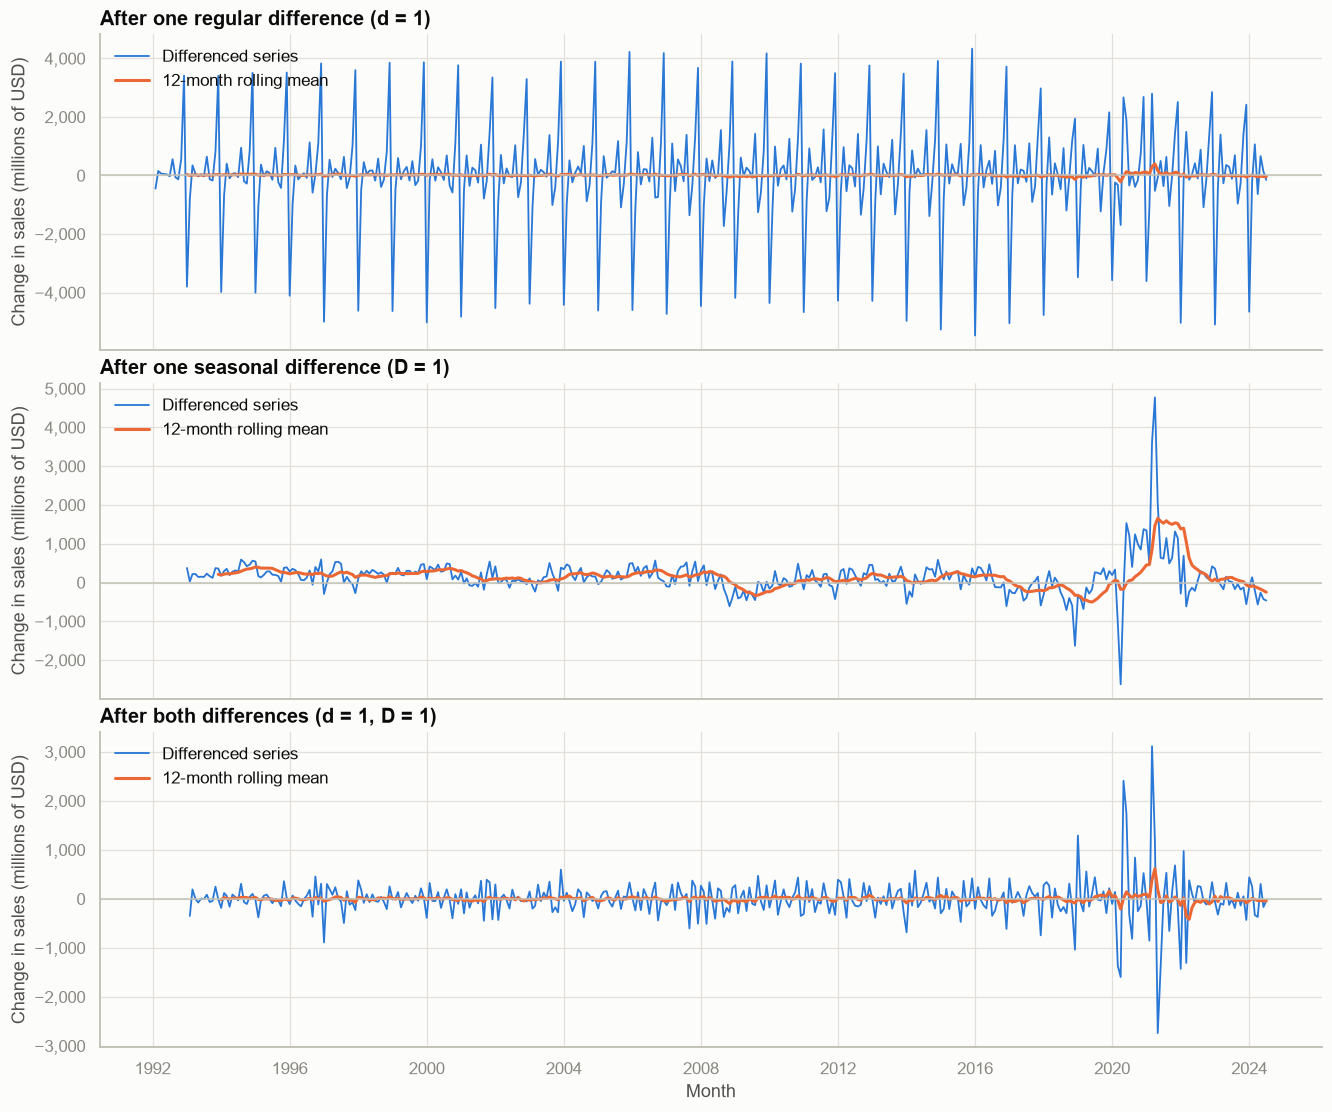

In [42]:
candidates = {
    "d = 1": train.diff(),
    "D = 1": train.diff(SEASONAL_PERIOD),
    "d = 1, D = 1": train.diff().diff(SEASONAL_PERIOD),
}
titles = ["After one regular difference (d = 1)", "After one seasonal difference (D = 1)",
          "After both differences (d = 1, D = 1)"]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, layout="constrained")
for ax, title, series in zip(axes, titles, candidates.values()):
    ax.plot(series, color=BLUE, lw=1.2, label="Differenced series")
    ax.plot(series.rolling(SEASONAL_PERIOD).mean(), color=ORANGE, label="12-month rolling mean")
    ax.axhline(0, color=AXIS, lw=1)
    ax.set(title=title, ylabel=f"Change in sales ({UNIT})")
    ax.yaxis.set_major_formatter("{x:,.0f}")
    ax.legend(loc="upper left")
axes[-1].set_xlabel("Month")
plt.show()

**Technical reading.**

- **Regular difference alone.** The rolling mean is flat and close to zero, so the trend is gone. The series itself still swings by several thousand every year, with the same spikes at the same dates: the seasonal pattern is untouched.
- **Seasonal difference alone.** The yearly spikes have disappeared and the scale is much smaller. The rolling mean, however, is not constant: it stays above zero in the 1990s and 2000s, goes below around 2008–2010 and 2017–2019, and jumps in 2020–2021. Part of the trend is still there.
- **Both differences.** The series fluctuates around zero over the whole period and its rolling mean stays flat. The only visible irregularity is the burst of 2020–2021.

**Business reading.**

- The month-to-month change mostly restates the calendar: sales fall every January because December was high. It says little about how the business is doing.
- The change from the same month of the previous year is the comparison retailers actually use. It shows runs of several years of growth followed by runs of decline, so "last year plus the usual increase" is not a rule that holds.
- Once both differences are applied, no lasting drift is left: what remains to be forecast is short-term movement around the path set by the previous year.

### 3.4 Tests on the differenced series

The first table gives the two tests for each candidate. The second gives, for the level and for each candidate, the moments that the tests do not look at directly.

In [43]:
display(pd.DataFrame({name: stationarity_tests(series) for name, series in candidates.items()}).T)
pd.DataFrame({name: moments(series) for name, series in {"level": train, **candidates}.items()}).T

,ADF statistic,ADF p-value,KPSS statistic,KPSS 5 % critical value,KPSS p-value,conclusion at 5 %
d = 1,-5.89,< 0.001,0.061,0.463,> 0.10,stationary
D = 1,-3.33,0.014,0.119,0.463,> 0.10,stationary
"d = 1, D = 1",-7.91,< 0.001,0.174,0.463,> 0.10,stationary


,mean,standard deviation,"autocorrelation, lag 1","autocorrelation, lag 12"
level,5954.0,1828.5,0.52,0.96
d = 1,12.1,1789.0,-0.28,0.97
D = 1,148.2,480.4,0.63,-0.16
"d = 1, D = 1",-2.2,413.6,-0.13,-0.38


**Technical reading.**

- **$d = 1$ passes both tests, and is still not stationary.** ADF rejects the unit root (−5.89) and KPSS does not reject stationarity (0.061). Yet the autocorrelation at lag 12 is 0.97 and the standard deviation (1,789) is barely below that of the level (1,829). Both tests look for a mean that drifts over time; neither is designed to see a pattern that repeats every 12 months. The mean of this series depends on the calendar month, so it is not stationary. **A seasonal difference is needed: $D = 1$.**
- **$D = 1$ alone removes the seasonal pattern.** The standard deviation falls to 480 and the autocorrelation at lag 12 to −0.16. Both tests conclude to stationarity at 5 %, but the evidence is weak: ADF rejects at 5 % and not at 1 % (p = 0.014), the autocorrelation at lag 1 is still 0.63, and the mean (148) is clearly not zero.
- **$d = 1$ and $D = 1$ together give a clear result.** ADF −7.91, KPSS 0.174, a mean close to zero (−2.2) and the lowest standard deviation of all (414). The autocorrelation at lag 1 is −0.13, far from the value of −0.5 that usually signals an over-differenced series.
- **What is left.** The autocorrelation at lag 12 is −0.38 after both differences. This remaining seasonal dependence is not a stationarity problem; it is what the seasonal terms of SARIMA will model in Section 5.

**Business reading.**

- Over the training period, a month is on average 148 million dollars above the same month of the previous year. The spread around that figure (480) is more than three times larger, which confirms that a fixed yearly increase is a poor planning rule.
- After both differences, the remaining standard deviation is about 414 million dollars, close to 5 % of a recent month (8,027 on average over the last 12 training months, see 2.5). This is the size of the surprises left once the calendar and the trend have been removed, before any model is fitted.

### 3.5 Robustness to the 2020–2021 shock

Section 1 showed that the training set contains a shock without precedent. Extreme values weigh on both tests, so the same computations are repeated on the training data up to December 2019.

In [44]:
before_shock = {name: series[:"2019-12"] for name, series in candidates.items()}
pd.DataFrame({name: {**stationarity_tests(series), **moments(series)} for name, series in before_shock.items()}).T

,ADF statistic,ADF p-value,KPSS statistic,KPSS 5 % critical value,KPSS p-value,conclusion at 5 %,mean,standard deviation,"autocorrelation, lag 1","autocorrelation, lag 12"
d = 1,-4.91,< 0.001,0.069,0.463,> 0.10,stationary,18.2,1795.3,-0.28,0.99
D = 1,-5.03,< 0.001,1.054,0.463,< 0.01,tests disagree,110.8,271.4,0.56,0.07
"d = 1, D = 1",-7.33,< 0.001,0.04,0.463,> 0.10,stationary,-0.2,253.4,-0.37,-0.13


**Technical reading.**

- **The verdict on $D = 1$ alone does not survive.** Without the shock, KPSS rejects stationarity (1.054 against 0.463) while ADF still rejects the unit root: the tests disagree. The favourable result of 3.4 was partly produced by the shock itself. The extreme values of 2020–2021 inflate the variance against which KPSS measures the drift of the mean, and that drift, visible in the plot of 3.3, goes unnoticed.
- **The verdict on $d = 1$, $D = 1$ is unchanged**: both tests conclude to stationarity, and its standard deviation (253) is again the lowest, below that of $D = 1$ alone (271).
- **The shock in one number.** The standard deviation of the twice-differenced series is 253 before 2020 and 414 over the whole training set.

**Business reading.** In ordinary years the remaining month-to-month surprise is about 250 million dollars, roughly 4 % of an average month of 2019 (6,336, see 2.4). The pandemic raises that measure by about 60 %. Models fitted on the whole training set will therefore produce prediction intervals wider than ordinary years alone would justify. For a planner this errs on the side of caution, at the price of more safety stock.

### 3.6 Conclusion

- The series in level is non-stationary: it has a random trend and a seasonal pattern.
- **$D = 1$** is required. The tests cannot see the seasonal pattern; the autocorrelation at lag 12 (0.97 after a regular difference alone) does.
- **$d = 1$** is retained as well. With both differences, the two tests conclude to stationarity with and without the 2020–2021 shock, the variance is the lowest, and there is no sign of over-differencing. With $D = 1$ alone, the conclusion depends on whether the shock is included.
- Section 5 therefore starts from **$d = 1$, $D = 1$, period 12**, and identifies the remaining AR and MA terms from the ACF and PACF of the twice-differenced series.

ETS and Prophet do not require a stationary series, since they model the trend and the seasonal pattern explicitly. What this section tells them is the nature of the trend: random, not a fixed line.

## 4. ETS: decomposition and Holt-Winters

> **To do** — planned content, to be replaced by the cells of this section.
>
> - **Band procedure**: curves through the yearly minima and maxima of the training series.
> - **Buys-Ballot table and test**: regression of the yearly standard deviation on the yearly mean, $\sigma_{p} = \alpha + \beta\,\bar{p} + \varepsilon$; significance of $\beta$ decides additive vs multiplicative.
> - **Analysis of variance**: Fisher tests of the seasonal (column) effect and the trend (row) effect.
> - Decomposition into trend, seasonal and residual components (period 12), additive vs multiplicative compared.
> - Seasonal coefficients and the conservation principle (sum to 0, or average to 1).
> - Holt-Winters / ETS fit: smoothing parameters, AIC/BIC, residual diagnostics.
> - Forecast over the test horizon with prediction intervals.

## 5. SARIMA

> **To do** — planned content, to be replaced by the cells of this section.
>
> - ACF and PACF of the differenced series.
> - Order selection $(p,d,q)(P,D,Q)_{12}$: candidates from the correlograms, compared by AIC/BIC.
> - Fit and coefficient significance.
> - Residual diagnostics: residual plot, ACF of residuals, Ljung-Box, histogram and QQ-plot.
> - Forecast over the test horizon with prediction intervals.

## 6. Prophet

> **To do** — planned content, to be replaced by the cells of this section.
>
> - Fit with yearly seasonality (weekly and daily off); additive vs multiplicative `seasonality_mode`.
> - Trend and yearly components.
> - Detected changepoints compared with documented economic events.
> - Forecast over the test horizon with uncertainty intervals.

## 7. Comparison of the forecasts

> **To do** — planned content, to be replaced by the cells of this section.
>
> - Baselines: naive and seasonal naive.
> - Metrics table (MAE, MSE, RMSE, MAPE) for the baselines and the three models on the same test set; what each metric penalises and which one matters most for the business case.
> - Overlaid plot of all forecasts against the actual values.
> - Discussion: accuracy, prediction intervals, interpretability, ease of maintenance.

## 8. Conclusion

> **To do** — planned content, to be replaced by the cells of this section.
>
> - Key findings.
> - Limits of the analysis.
> - Business recommendations.
> - Possible improvements.

## 9. AI-usage policy

> **To do** — planned content, to be replaced by the cells of this section.
>
> - Major prompts and how AI was used, built from `AI_USAGE_LOG.md`.